# Evaluation

In [1]:
import itertools
import json
import pathlib

import itables
import matplotlib.pyplot as plt
import numpy
import pandas

In [2]:
INPUT_DIRS = ['machines']
INPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.txt'), INPUT_DIRS)))

## Info

In [3]:
import evaluate
MACHINES = evaluate._um_read_stats_as_dataframe(INPUT)
itables.show(MACHINES)

Loading ITables v2.8.0 from the internet... (need help?)


## Runs

In [4]:
# last updated: 2026-06-05
PRICING = {
    # https://platform.claude.com/docs/en/about-claude/pricing
    'anthropic': {
        'claude-opus-4-8': (5./1e6, 25./1e6),
        'claude-opus-4-7': (5./1e6, 25./1e6),
    },
    # https://api-docs.deepseek.com/quick_start/pricing/
    'deepseek': {
        'deepseek-v4-pro':   (.435/1e6, .87/1e6), 
        'deepseek-v4-flash': (.14/1e6,  .28/1e6), 
    },
    # https://ai.google.dev/gemini-api/docs/pricing
    'google-genai': {
        'gemini-3.1-pro-preview': (4./1e6, 18./1e6),
        'gemini-2.5-pro':         (2.5/1e6, 15./1e6),
    },
    # https://developers.openai.com/api/docs/pricing
    'openai': {
        'gpt-5.5':      (5.0/1e6,  30./1e6),
        'gpt-5.4':      (2.5/1e6,  15./1e6), 
        'gpt-5.2':      (1.75/1e6, 14./1e6),
        'gpt-5.4-mini': (.75/1e6,  4.5/1e6),
        'gpt-5.4-nano': (.20/1e6,  1.25/1e6)}}

def cost(provider, model, input_tokens, output_tokens):
    try:
        l, r = PRICING[provider][model]
        return l * input_tokens + r * output_tokens
    except KeyError as err:
        return 0.

In [5]:
ABBREV = {
    'deepseek-v4-pro': 'DSV4',
    'gemini-2.5-pro': 'GEM2.5',
    'gpt-5.4': 'GPT5.4',
    'gpt-5.2': 'GPT5.2',
}

In [6]:
def load(runs, skip=lambda x: False):
    for path in runs:
        with open(path, 'rt', encoding='utf-8') as fp:
            t = json.load(fp)
            if skip(t):
                continue
            yield {
                #'path': str(path),
                'D': t['digest'],
                'Q': t['num_states'],
                'S': t['num_symbols'],
                'W': t['work_length'],
                'C': t['cycles_until_halt'],
                'provider': t['provider'],
                'model': ABBREV[t['model']] + ('' if t['truncate'] is None else '(tr)'),
                #'prompt': t['prompt'],
                #'temperature': t['temperature'],
                #'seed': t['seed'],
                'truncate': f'yes({t["truncate"]})' if t['truncate'] is not None else 'no',
                'cycles': t['cycles'],
                'progress': t['cycles'] / t['cycles_until_halt'],
                'error': bool(t['error']),
                'halted': bool(t['halted']),
                'input_tokens': t['usage_metadata']['input_tokens'],
                'output_tokens': t['usage_metadata']['output_tokens'],
                'cost': cost(t['provider'],
                             t['model'],
                             t['usage_metadata']['input_tokens'],
                             t['usage_metadata']['output_tokens']),
            }

In [7]:
OUTPUT_DIRS = ['runs']
OUTPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.json'), OUTPUT_DIRS)))
SKIP = lambda t: t['model'] in ('claude-opus-4-8', 'gpt-5.5')
RUNS = pandas.DataFrame(list(load(OUTPUT, SKIP)))
RUNS_SUM = RUNS[['error', 'halted']].sum().to_frame(name='sum')
RUNS_COST = RUNS[['cost']].sum().to_frame(name='$')
display(RUNS_SUM)
display(RUNS_COST)
itables.show(RUNS)

,sum
error,714
halted,214


,$
cost,371.829803


Loading ITables v2.8.0 from the internet... (need help?)


## Runs per model

In [8]:
CFG_Ds = sorted(RUNS['D'].unique())
CFG_Qs = sorted(RUNS['Q'].unique())
CFG_Ss = sorted(RUNS['S'].unique())
CFG_Ws = sorted(RUNS['W'].unique())
CFG_Cs = sorted(RUNS['C'].unique())
CFG_MODELS = sorted(RUNS['model'].unique())
RUNS_PER_MODEL = {model: RUNS[RUNS['model'] == model] for model in CFG_MODELS}
display(CFG_Qs, CFG_Ss, CFG_Ws, CFG_Cs)

[np.int64(2), np.int64(4), np.int64(8)]

[np.int64(2)]

[np.int64(8), np.int64(16), np.int64(32), np.int64(64)]

[np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128)]

In [9]:
RUNS_PER_MODEL_STATS = pandas.DataFrame([{'model': k, 'runs': len(t), '%': len(t) / len(MACHINES) * 100} for k, t in RUNS_PER_MODEL.items()])
RUNS_PER_MODEL_STATS

,model,runs,%
0,DSV4,116,100.0
1,DSV4(tr),116,100.0
2,GEM2.5,116,100.0
3,GEM2.5(tr),116,100.0
4,GPT5.2,116,100.0
5,GPT5.2(tr),116,100.0
6,GPT5.4,116,100.0
7,GPT5.4(tr),116,100.0


In [10]:
RUNS.groupby('model').apply(len)

model
DSV4          116
DSV4(tr)      116
GEM2.5        116
GEM2.5(tr)    116
GPT5.2        116
GPT5.2(tr)    116
GPT5.4        116
GPT5.4(tr)    116
dtype: int64

## Cost

In [11]:
df = RUNS.groupby('model').apply(lambda t: t[['input_tokens', 'output_tokens', 'cost']].sum()).astype({'input_tokens': int, 'output_tokens': int, 'cost': float})
df['avg_input_tokens'] = df['input_tokens'] / 116
df['avg_output_tokens'] = df['output_tokens'] / 116
df['avg_cost'] = df['cost'] / 116
display(df)
display(df[['cost', 'avg_cost']].sum().round(2))
# #!pip install millify
# import millify
# import functools
M = lambda x: f'{round(x/1e3):,}K'
f = lambda x: f'{x:.2f}'
df['input_tokens'] = df['input_tokens'].apply(M)
df['output_tokens'] = df['output_tokens'].apply(M)
df['cost'] = df['cost'].apply(f)
df['avg_input_tokens'] = df['avg_input_tokens'].apply(M)
df['avg_output_tokens'] = df['avg_output_tokens'].apply(M)
df['avg_cost'] = df['avg_cost'].apply(f)
df.T

,input_tokens,output_tokens,cost,avg_input_tokens,avg_output_tokens,avg_cost
model,,,,,,
DSV4,5103128,2171670,4.109214,43992.482759,18721.293103,0.035424
DSV4(tr),1448303,5415965,5.341901,12485.370690,46689.353448,0.046051
GEM2.5,53882346,4264586,198.674655,464502.982759,36763.672414,1.712713
GEM2.5(tr),2035001,4403551,71.140768,17543.112069,37961.646552,0.613282
GPT5.2,18119829,670316,41.094125,156205.422414,5778.586207,0.354260
GPT5.2(tr),653983,361862,6.210538,5637.784483,3119.500000,0.053539
GPT5.4,9447899,664982,33.594477,81447.405172,5732.603448,0.289608
GPT5.4(tr),1278068,564597,11.664125,11017.827586,4867.215517,0.100553


cost        371.83
avg_cost      3.21
dtype: float64

model,DSV4,DSV4(tr),GEM2.5,GEM2.5(tr),GPT5.2,GPT5.2(tr),GPT5.4,GPT5.4(tr)
input_tokens,"5,103K","1,448K","53,882K","2,035K","18,120K",654K,"9,448K","1,278K"
output_tokens,"2,172K","5,416K","4,265K","4,404K",670K,362K,665K,565K
cost,4.11,5.34,198.67,71.14,41.09,6.21,33.59,11.66
avg_input_tokens,44K,12K,465K,18K,156K,6K,81K,11K
avg_output_tokens,19K,47K,37K,38K,6K,3K,6K,5K
avg_cost,0.04,0.05,1.71,0.61,0.35,0.05,0.29,0.10


## Progress

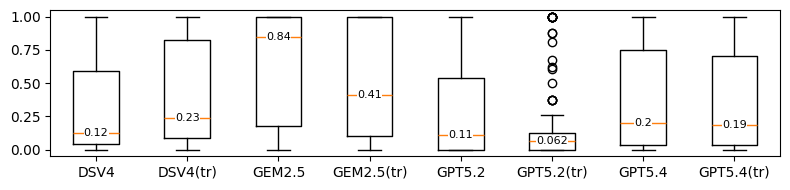

In [12]:
fig, ax = plt.subplots(figsize=(8,2))
labels, data = list(zip(*((k, t['progress']) for k, t in RUNS_PER_MODEL.items())))
bp = ax.boxplot(data, tick_labels=labels)
for line in bp['medians']:
    xs, ys = line.get_xdata(), line.get_ydata()
    x, y = numpy.mean(xs), numpy.mean(ys)
    if not numpy.isnan(y):
        ax.annotate(
            f'{y:.2g}' if (y < 1.) else f'{round(y)}',
            (x, y), ha='center', va='center',
            color='black', fontsize=8, bbox={
                'boxstyle': 'square,pad=.01',
                'facecolor': 'white',
                'linewidth': .0})
ax.tick_params(axis='x', labelrotation=0)
#ax.grid(axis='y')
fig.tight_layout()
plt.savefig('figs/progress.pdf', format='pdf')
plt.show()

In [13]:
pandas.DataFrame({'model': k, 'median progress': v['progress'].median()} for k, v in RUNS_PER_MODEL.items()).sort_values(by=['median progress'], ascending=False)

,model,median progress
2,GEM2.5,0.843750
3,GEM2.5(tr),0.414062
1,DSV4(tr),0.234375
6,GPT5.4,0.203125
7,GPT5.4(tr),0.187500
0,DSV4,0.125000
4,GPT5.2,0.109375
5,GPT5.2(tr),0.062500


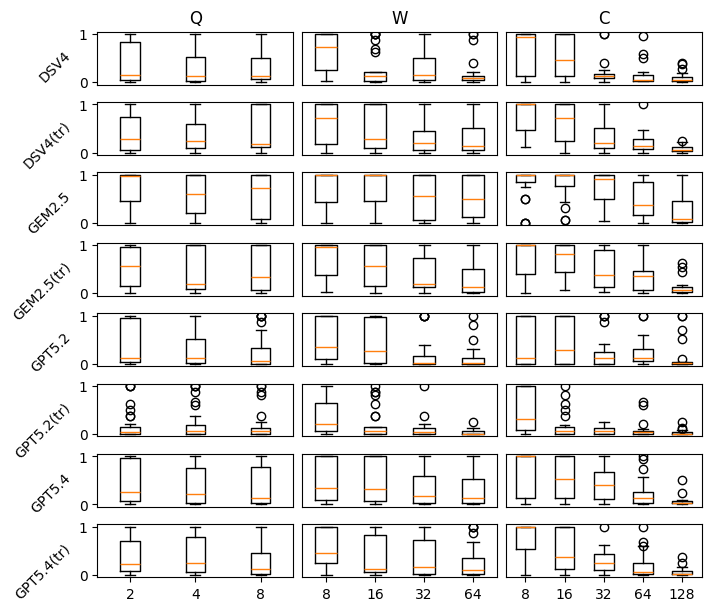

In [24]:
fig = plt.figure(figsize=(7,6), constrained_layout=True)
nrows, ncols = len(RUNS_PER_MODEL), 3
for i, (k, t) in enumerate(RUNS_PER_MODEL.items()):
    axQ = fig.add_subplot(nrows, ncols, i * ncols + 1)
    axQ.boxplot([t[t['Q'] == n]['progress'] for n in CFG_Qs], tick_labels=CFG_Qs)
    axW = fig.add_subplot(nrows, ncols, i * ncols + 2)
    axW.boxplot([t[t['W'] == n]['progress'] for n in CFG_Ws], tick_labels=CFG_Ws)
    axC = fig.add_subplot(nrows, ncols, i * ncols + 3)
    axC.boxplot([t[t['C'] == n]['progress'] for n in CFG_Cs], tick_labels=CFG_Cs)
    if i == 0:
        axQ.set_title('Q')
        axW.set_title('W')
        axC.set_title('C')
    axQ.set_ylabel(k, rotation=45, ha='right')
    axQ.get_xaxis().set_visible(False)
    axW.get_xaxis().set_visible(False)
    axC.get_xaxis().set_visible(False)
    axW.get_yaxis().set_visible(False)
    axC.get_yaxis().set_visible(False)
axQ.get_xaxis().set_visible(True)
axW.get_xaxis().set_visible(True)
axC.get_xaxis().set_visible(True)
#fig.tight_layout()
plt.savefig('figs/progress-detailed.pdf', format='pdf')
plt.show()

## Accuracy

In [15]:
def it():
    N = list(range(0, CFG_Cs[-1] + 1))
    for k, t in RUNS_PER_MODEL.items(): 
        N_correct = pandas.Series([len(t[t['cycles'] >= i]) for i in N])
        N_total = pandas.Series([len(t[t['C'] >= i]) for i in N])
        yield pandas.DataFrame(N_correct / N_total, columns=[k])
ACC = pandas.concat(it(), axis=1)
ACC

,DSV4,DSV4(tr),GEM2.5,GEM2.5(tr),GPT5.2,GPT5.2(tr),GPT5.4,GPT5.4(tr)
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,0.965517,0.931034,0.939655,0.948276,0.724138,0.706897,0.905172,0.887931
2,0.775862,0.879310,0.870690,0.862069,0.560345,0.500000,0.801724,0.750000
3,0.672414,0.810345,0.862069,0.801724,0.551724,0.413793,0.732759,0.663793
4,0.612069,0.775862,0.862069,0.784483,0.525862,0.344828,0.663793,0.612069
...,...,...,...,...,...,...,...,...
124,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000
125,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000
126,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000
127,0.000000,0.000000,0.181818,0.000000,0.090909,0.000000,0.000000,0.000000


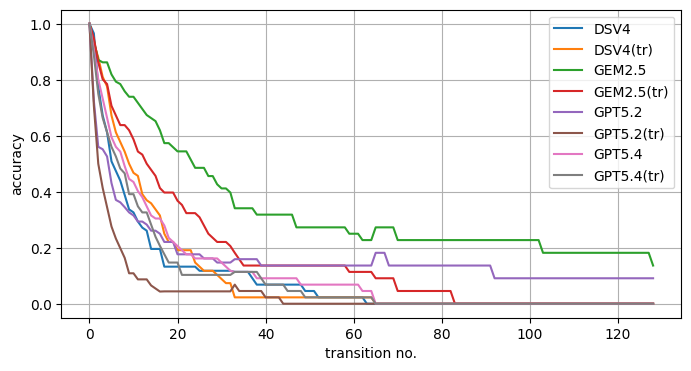

In [16]:
fig, ax = plt.subplots(figsize=(8,4))
ACC.plot.line(grid=True, ax=ax)
ax.set_ylabel('accuracy')
ax.set_xlabel('transition no.')
plt.savefig('figs/accuracy.pdf', format='pdf')
plt.show()

In [17]:
#ACC[['deepseek-v4-pro', 'deepseek-v4-pro(tr)']].plot.line(grid=True)

In [18]:
#ACC[['gemini-2.5-pro', 'gemini-2.5-pro(tr)']].plot.line(grid=True)

In [19]:
#ACC[['gpt-5.2', 'gpt-5.2(tr)']].plot.line(grid=True)

In [20]:
#ACC[['gpt-5.4', 'gpt-5.4(tr)']].plot.line(grid=True)

# Variants

In [21]:
import evaluate
HALTED_RUNS = RUNS[RUNS['halted'] == True]
HALTED_RUNS.groupby(['model']).apply(lambda x: x)
ALL_MODELS = set(CFG_MODELS)
display(ALL_MODELS)
SRC_Ds = [d for d in HALTED_RUNS['D'].unique() if set(HALTED_RUNS[HALTED_RUNS['D'] == d]['model'].values) == ALL_MODELS]
SRC_Ds

{'DSV4',
 'DSV4(tr)',
 'GEM2.5',
 'GEM2.5(tr)',
 'GPT5.2',
 'GPT5.2(tr)',
 'GPT5.4',
 'GPT5.4(tr)'}

['3697aba8466a1891198569358e2784441c62b22887b9efb0257e7bd9156e4179']

In [22]:
# SRC_PATHS = [next(pathlib.Path('machines').glob(f'*-{d}.txt')) for d in SRC_Ds]
# VARDIR = pathlib.Path('machines.variants')
# VARDIR.mkdir(exist_ok=True)
# for path in SRC_PATHS:
#     varpath = VARDIR / (path.stem + '-variant.txt')
#     print('writting variant ', varpath)
#     evaluate._um_gen_variant(path).dump_file(varpath)

In [23]:
# VAR_OUTPUT_DIRS = ['runs.variants']
# VAR_OUTPUT = list(itertools.chain(*map(lambda x: pathlib.Path(x).glob('*.json'), VAR_OUTPUT_DIRS)))
# VARS = pandas.DataFrame(list(load(VAR_OUTPUT)))
# itables.show(VARS)